In [6]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import defaultdict

In [2]:

root = Path("/home/linux/Desktop/Dataset/")  # replace with your top-level directory
files = list(root.rglob("*.jsonl"))
total_files = len(files) # Count the number of files
records = []
file_count = 0
line_count = 0
bad_lines = 0
total_lines_to_process = 0

# Iterate through each file in the list 'files'
for file in files:
    # Open each file in read mode with UTF-8 encoding
    with file.open("r", encoding="utf-8") as f:
        # Count each line in the current file
        for line in f:
            total_lines_to_process += 1  # Increment the line counter

# Print out the total number of files and the total lines to process
print(f"Total files: {total_files}, Total lines to process: {total_lines_to_process}")

Total files: 3, Total lines to process: 60000


In [3]:
for p in files:
    file_count += 1
    print(f"Processing file {file_count}/{total_files}: {p}")
    with p.open("r", encoding="utf-8") as f:
        for i, raw in enumerate(f, start=1):
            raw = raw.strip()
            if not raw:
                continue
            try:
                records.append(json.loads(raw))
                line_count += 1
            except json.JSONDecodeError:
                bad_lines += 1
    print(f"  -> lines read: {i}, valid records so far: {line_count}, bad lines so far: {bad_lines}")

df = pd.DataFrame.from_records(records)
print(f"Finished. Files: {total_files}, Records: {len(df)}, Bad lines: {bad_lines}")

Processing file 1/3: /home/linux/Desktop/Dataset/2023-11-05_2023-11-11_Win64_train.jsonl
  -> lines read: 20000, valid records so far: 20000, bad lines so far: 0
Processing file 2/3: /home/linux/Desktop/Dataset/1_train.jsonl
  -> lines read: 20000, valid records so far: 40000, bad lines so far: 0
Processing file 3/3: /home/linux/Desktop/Dataset/2023-10-29_2023-11-04_Win64_train.jsonl
  -> lines read: 20000, valid records so far: 60000, bad lines so far: 0
Finished. Files: 3, Records: 60000, Bad lines: 0


In [4]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   md5                    60000 non-null  str    
 1   sha1                   60000 non-null  str    
 2   sha256                 60000 non-null  str    
 3   tlsh                   60000 non-null  str    
 4   first_submission_date  60000 non-null  int64  
 5   last_analysis_date     60000 non-null  int64  
 6   detection_ratio        60000 non-null  str    
 7   label                  60000 non-null  int64  
 8   file_type              60000 non-null  str    
 9   family                 24704 non-null  str    
 10  family_confidence      24704 non-null  float64
 11  behavior               60000 non-null  object 
 12  file_property          60000 non-null  object 
 13  packer                 60000 non-null  object 
 14  exploit                60000 non-null  object 
 15  group        

,md5,sha1,sha256,tlsh,first_submission_date,last_analysis_date,detection_ratio,label,file_type,family,...,imports,exports,datadirectories,richheader,authenticode,pefilewarnings,week_id,caps,ttps,mbc
0,ad5cf31f8322db0ca568ccca699c767f,d225c3158d5af540f0723399ebdd92ea418cc4d6,00068ab2c8dca97f9df22779d4eb65fe0d9377a7247790...,T1848633427A5204FADDF810368412C134E2767CBB47B0...,1699645720,1702536804,5/76,1,Win64,NaN,...,"{'KERNEL32.dll': ['GetCommandLineW', 'GetEnvir...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[17004619, 7, 17135691, 190, 17070155, 10, 166...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[Failed parsing FunctionEntry of UNWIND_INFO a...,6,[],[],[]
1,d61de691e80b072d3dd41f5626cece88,ce76b2c09087bb0fe68cb78081cc4acbdf8c5abe,000afe1301d6331a924b0e31c8b8e483b01f1245c6f4bb...,T17F235B0FE21380B9D31B523449667676F836B91922B0...,1699623928,1707299644,31/76,1,Win64,cosmu,...,{},[],"[{'has_relocs': 0, 'has_dynamic_relocs': 0}, {...",[],"{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Damaged Import Table information..., Error pa...",6,[],[],[]
2,57d5fca7f89e62979487537db4d1e840,9688832b41753181e38269b1844e8c1ca3efade6,001000780a9b049cc5301566714a2ba0738270045e2234...,T1E166336461A10EF5ECF7913AC88499549AB3B06343A4...,1699187757,1699978806,43/76,1,Win64,stubo,...,"{'USER32.dll': ['CreateWindowExW', 'MessageBox...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[17004619, 7, 17135691, 191, 17070155, 10, 166...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[Failed parsing FunctionEntry of UNWIND_INFO a...,6,[],[],[]
3,b94441a20f310d96c33d2970408a8fc0,dff7a373b51ccd6835344c9dba1cb8a210da3440,001a83827a3bb4ad8f9cfdefd748a10e9859251ce0cdf0...,T1F055120D07ED24DAF43356B49666819687B4BC712720...,1699356858,1699516200,49/76,1,Win64,expiro,...,"{'ADVAPI32.dll': ['GetTokenInformation', 'SetS...",[],"[{'has_relocs': 0, 'has_dynamic_relocs': 0}, {...","[17001236, 3, 17132308, 16, 16870164, 13, 6553...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Byte 0x..., Suspicious flags set for section...]",6,[],[],[]
4,285867934e6c3e6f6649221b1f252ff7,6023d698b52519a48010fbf30afb481afc30f4d9,001af6bc132767957af589115f7044dbe6145c604f0988...,T1A0256E4273FC1128F0F75F57BE767554A97EBEEA6A41...,1699635141,1720921143,0/77,0,Win64,NaN,...,{'mscoree.dll': ['_CorDllMain']},[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...",[],"{'num_certs': 2, 'self_signed': 0, 'empty_prog...",[],6,"[{'Capability': 'Access .net resource', 'Names...",[],"[{'Objective': 'DISCOVERY', 'Behavior': 'Analy..."


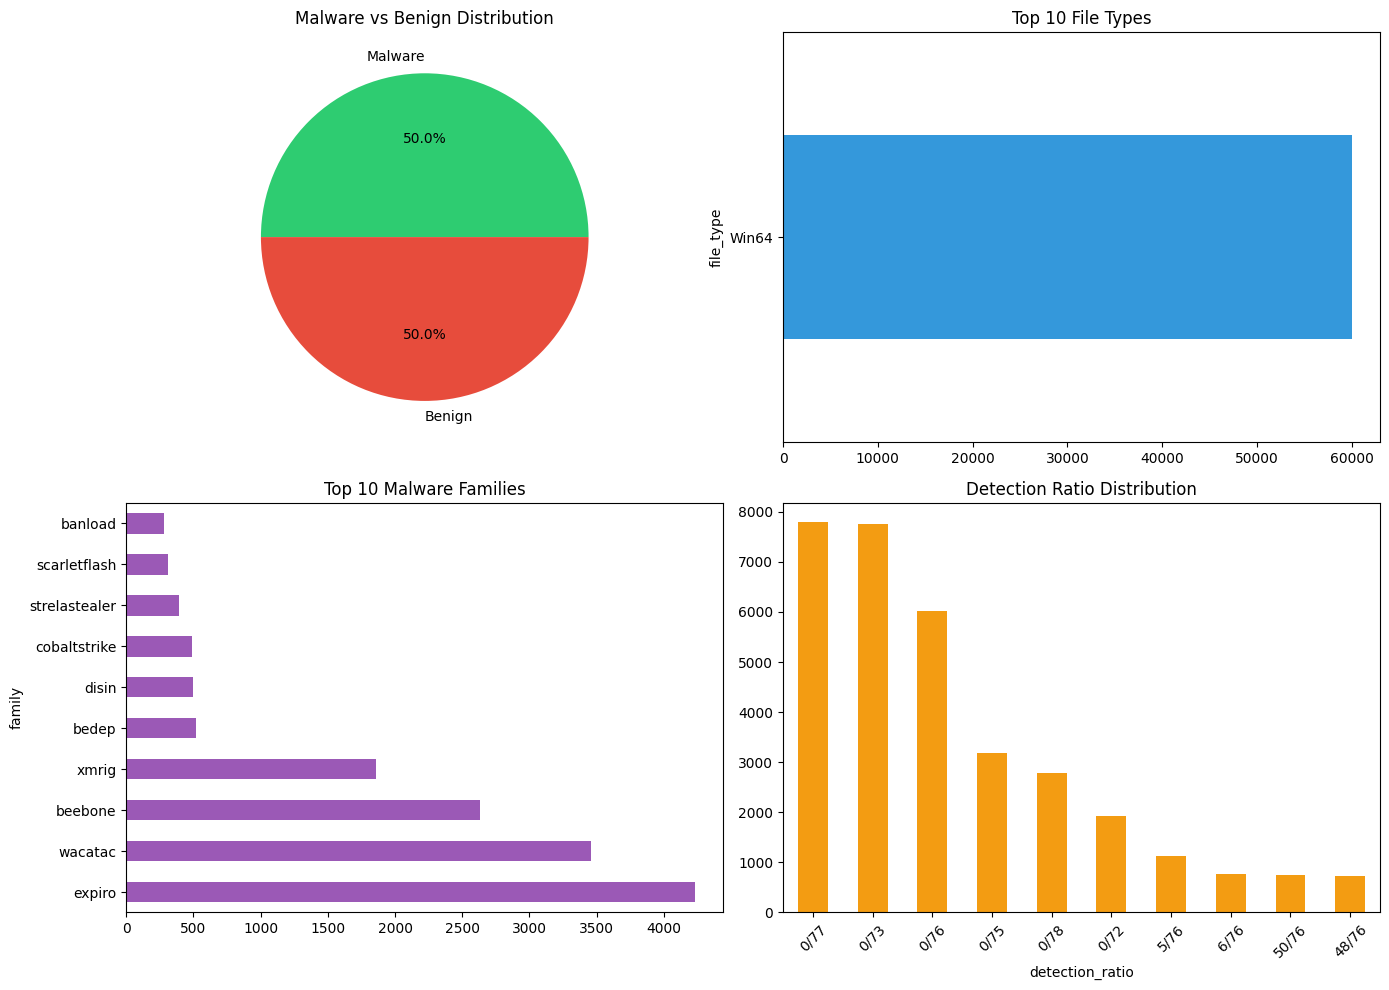

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Label distribution
label_counts = df['label'].value_counts()
axes[0,0].pie(label_counts.values, labels=['Benign' if x==0 else 'Malware' for x in label_counts.index], 
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Malware vs Benign Distribution')

# File type distribution (top 10)
df['file_type'].value_counts().head(10).plot(kind='barh', ax=axes[0,1], color='#3498db')
axes[0,1].set_title('Top 10 File Types')

# Family distribution (top 10, excluding NaN)
df['family'].value_counts().head(10).plot(kind='barh', ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Top 10 Malware Families')

# Detection ratio distribution
df['detection_ratio'].value_counts().head(10).plot(kind='bar', ax=axes[1,1], color='#f39c12')
axes[1,1].set_title('Detection Ratio Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('malware_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import thrember
from pathlib import Path

I0000 00:00:1774256263.776765   75772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774256264.145002   75772 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774256265.458632   75772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/marcelino/Documents/GitHub/DAML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please upd

In [3]:
import numpy as np

# Monkey-patch the function to avoid MemoryError
original_read = thrember.read_vectorized_features

def patched_read(data_dir, subset="train"):
    """Patched version that returns memmap instead of array"""
    data_dir = Path(data_dir)
    X_path = data_dir / f"X_{subset}.dat"
    y_path = data_dir / f"y_{subset}.dat"
    
    extractor = thrember.PEFeatureExtractor()
    ndim = extractor.dim
    
    # Return memmap objects (act like arrays but stay on disk)
    X = np.memmap(X_path, dtype=np.float32, mode="r").reshape(-1, ndim)
    y = np.memmap(y_path, dtype=np.int32, mode="r")
    
    return X, y
import numpy as np
# Monkey-patch the function to avoid MemoryError
original_read = thrember.read_vectorized_features
def patched_read(data_dir, subset="train"):
    """Patched version that returns memmap instead of array"""
    data_dir = Path(data_dir)
    X_path = data_dir / f"X_{subset}.dat"
    y_path = data_dir / f"y_{subset}.dat"

    extractor = thrember.PEFeatureExtractor()
    ndim = extractor.dim

    # Return memmap objects (act like arrays but stay on disk)
    X = np.memmap(X_path, dtype=np.float32, mode="r").reshape(-1, ndim)
    y = np.memmap(y_path, dtype=np.int32, mode="r")

    return X, y
# Replace the function
thrember.read_vectorized_features = patched_read
# Now your original code works without MemoryError
x_train, y_train = thrember.read_vectorized_features('/home/marcelino/Desktop/Data/Dataset/Vectorised-Data', subset="train")
x_test, y_test = thrember.read_vectorized_features('/home/marcelino/Desktop/Data/Dataset/Vectorised-Data', subset="test")
print(f"Type: {type(x_train)}, Shape: {x_train.shape}, Memory usage: {x_train.nbytes / 1e9:.2f} GB (file-backed: {hasattr(x_train, 'filename')})")

Type: <class 'numpy.memmap'>, Shape: (4160000, 2568), Memory usage: 42.73 GB (file-backed: True)


In [4]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import os
import time
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

In [5]:
# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ─── Hardware Config ──────────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(8, os.cpu_count())     # i9-12900K has plenty of cores
PIN_MEMORY  = DEVICE.type == "cuda"

print(f"[Device]   {DEVICE}")
if DEVICE.type == "cuda":
    print(f"[GPU]      {torch.cuda.get_device_name(0)}")
    print(f"[VRAM]     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

[Device]   cuda
[GPU]      NVIDIA GeForce RTX 4080
[VRAM]     16.7 GB


In [6]:
# ─── Feature Reshaping Config ─────────────────────────────────────────────────
# EMBER PEFeatureExtractor produces 2381-D vectors.
# We pad to 2400 = 48 × 50 and treat as a length-48 sequence.
ORIG_DIM     = x_train.shape[1]   # 2381
N_TIMESTEPS  = 48
N_FEATURES   = 50
PADDED_DIM   = N_TIMESTEPS * N_FEATURES   # 2400
PAD_WIDTH    = PADDED_DIM - ORIG_DIM      # 19 zeros appended

print(f"[Features] original={ORIG_DIM}  padded={PADDED_DIM}  "
      f"→ sequence ({N_TIMESTEPS} steps × {N_FEATURES} features)")

[Features] original=2568  padded=2400  → sequence (48 steps × 50 features)


In [7]:
# ─── Hyper-parameters ─────────────────────────────────────────────────────────
LSTM_HIDDEN  = 256
LSTM_LAYERS  = 2
DROPOUT      = 0.30
BATCH_SIZE   = 4096   # fits comfortably with mixed-precision on 24GB GPU;
                      # reduce to 2048 if OOM
EPOCHS       = 15
LR           = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0
LABEL_SMOOTH = 0.05   # helps with noisy AV labels
PATIENCE     = 3      # early-stop patience

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 1.  DATASET  (disk-backed, zero-copy)
# ══════════════════════════════════════════════════════════════════════════════
class EmberMemmapDataset(Dataset):
    """
    Wraps numpy memmaps so the data stays on disk.
    Each __getitem__ reads only the needed row → no RAM explosion.
    """

    def __init__(self, X: np.memmap, y: np.memmap,
                 pad_to: int = PADDED_DIM,
                 n_timesteps: int = N_TIMESTEPS,
                 n_features: int = N_FEATURES,
                 normalize: bool = True,
                 mean: np.ndarray = None,
                 std: np.ndarray = None):
        self.X          = X
        self.y          = y
        self.pad_to     = pad_to
        self.n_timesteps = n_timesteps
        self.n_features  = n_features

        # Per-feature statistics for z-score normalisation.
        # Compute once from a random subsample to keep RAM usage low.
        if normalize:
            if mean is None or std is None:
                print("[Dataset]  Computing feature statistics from 100k subsample …")
                idx  = np.random.choice(len(X), size=min(100_000, len(X)),
                                        replace=False)
                sub  = X[idx].astype(np.float32)
                self.mean = sub.mean(axis=0)
                self.std  = sub.std(axis=0) + 1e-7
                del sub
                print("[Dataset]  Done.")
            else:
                self.mean = mean
                self.std  = std
        else:
            self.mean = np.zeros(X.shape[1], dtype=np.float32)
            self.std  = np.ones(X.shape[1],  dtype=np.float32)

    def get_stats(self):
        """Return (mean, std) so the test set can reuse train statistics."""
        return self.mean, self.std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].reshape(24, 107)  # 24 × 107 = 2568 exactly
        y = int(self.y[idx] > 0)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

: 

In [ ]:










# ══════════════════════════════════════════════════════════════════════════════
# 2.  MODEL
# ══════════════════════════════════════════════════════════════════════════════
class EmberLSTM(nn.Module):
    """
    Bidirectional LSTM classifier for PE malware detection.

    Architecture
    ────────────
    Input       : (batch, seq=48, feat=50)
    InputProj   : Linear 50 → 128           (learn a better embedding space)
    BiLSTM ×2   : hidden=256 per direction
    Attention   : learnable temporal pooling (replaces last-hidden heuristic)
    Classifier  : LayerNorm → Dropout → Linear 512 → 128 → 1
    Output      : raw logit (use BCEWithLogitsLoss during training)
    """

    def __init__(self,
                 n_features:  int = N_FEATURES,
                 hidden_size: int = LSTM_HIDDEN,
                 n_layers:    int = LSTM_LAYERS,
                 dropout:     float = DROPOUT):
        super().__init__()

        proj_dim = 128

        # ── Input projection ──────────────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(107, 128),   # ← was 50, now 107
            nn.LayerNorm(128),
            nn.GELU()
        )

        # ── Bidirectional LSTM ────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )

        lstm_out_dim = hidden_size * 2   # bidirectional

        # ── Learnable attention pooling ───────────────────────────────────
        self.attn = nn.Linear(lstm_out_dim, 1, bias=False)

        # ── Classifier head ───────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_out_dim),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # x: (B, T, F)
        x = self.input_proj(x)                          # (B, T, proj_dim)

        lstm_out, _ = self.lstm(x)                      # (B, T, 2H)

        # Attention pooling over timesteps
        scores = self.attn(lstm_out).squeeze(-1)        # (B, T)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        context = (lstm_out * weights).sum(dim=1)       # (B, 2H)

        logit = self.classifier(context).squeeze(-1)   # (B,)
        return logit


# ══════════════════════════════════════════════════════════════════════════════
# 3.  LABEL-SMOOTHED LOSS
# ══════════════════════════════════════════════════════════════════════════════
class LabelSmoothBCE(nn.Module):
    def __init__(self, smoothing: float = LABEL_SMOOTH):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(logits, targets_smooth)


# ══════════════════════════════════════════════════════════════════════════════
# 4.  TRAINING LOOP HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def run_epoch(model, loader, criterion, optimizer, scaler,
              device, train=True, desc="Train"):
    model.train(train)
    total_loss = 0.0
    all_labels, all_probs = [], []

    for step, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            logits = model(xb)
            loss   = criterion(logits, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item()
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(yb.cpu().numpy().tolist())

        if train and (step % 50 == 0):
            print(f"  [{desc}] step {step:>5}/{len(loader)}  "
                  f"loss={loss.item():.4f}", flush=True)

    preds = (np.array(all_probs) >= 0.5).astype(int)
    acc   = accuracy_score(all_labels, preds)
    auc   = roc_auc_score(all_labels, all_probs)
    f1    = f1_score(all_labels, preds, zero_division=0)
    avg_loss = total_loss / len(loader)
    return avg_loss, acc, auc, f1


# ══════════════════════════════════════════════════════════════════════════════
# 5.  MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():
    # ── Datasets & Loaders ────────────────────────────────────────────────
    print("\n[1/4] Building datasets …")
    train_ds = EmberMemmapDataset(x_train, y_train)
    mean, std = train_ds.get_stats()

    test_ds  = EmberMemmapDataset(x_test,  y_test,
                                  normalize=True, mean=mean, std=std)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )
    test_loader  = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )

    print(f"  Train samples : {len(train_ds):,}")
    print(f"  Test  samples : {len(test_ds):,}")

    # ── Model ─────────────────────────────────────────────────────────────
    print("\n[2/4] Initialising model …")
    model = EmberLSTM().to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable parameters: {n_params:,}")
    print(model)

    # ── Optimiser & Scheduler ─────────────────────────────────────────────
    criterion = LabelSmoothBCE().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LR, weight_decay=WEIGHT_DECAY)
    # Cosine annealing; restarts every 5 epochs to escape local minima
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=1, eta_min=1e-6)

    scaler = torch.amp.GradScaler('cuda')   # mixed-precision

    # ── Training ──────────────────────────────────────────────────────────
    print("\n[3/4] Training …")
    history = []
    best_auc  = 0.0
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        print(f"\n{'─'*60}")
        print(f"Epoch {epoch}/{EPOCHS}   LR={scheduler.get_last_lr()[0]:.2e}")

        tr_loss, tr_acc, tr_auc, tr_f1 = run_epoch(
            model, train_loader, criterion, optimizer, scaler,
            DEVICE, train=True, desc="Train")

        with torch.no_grad():
            va_loss, va_acc, va_auc, va_f1 = run_epoch(
                model, test_loader, criterion, optimizer, scaler,
                DEVICE, train=False, desc="Test ")

        scheduler.step()

        elapsed = time.time() - t0
        print(f"\n  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}  "
              f"auc={tr_auc:.4f}  f1={tr_f1:.4f}")
        print(f"  Test   loss={va_loss:.4f}  acc={va_acc:.4f}  "
              f"auc={va_auc:.4f}  f1={va_f1:.4f}")
        print(f"  Time   {elapsed/60:.1f} min")

        history.append(dict(epoch=epoch,
                            tr_loss=tr_loss, tr_acc=tr_acc,
                            tr_auc=tr_auc,   tr_f1=tr_f1,
                            va_loss=va_loss, va_acc=va_acc,
                            va_auc=va_auc,   va_f1=va_f1))

        # Checkpoint
        if va_auc > best_auc:
            best_auc = va_auc
            no_improve = 0
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "opt_state":   optimizer.state_dict(),
                "auc":         best_auc,
                "mean":        mean,
                "std":         std,
            }, "ember2024_lstm_best.pt")
            print(f"  ✓ Checkpoint saved  (best AUC={best_auc:.5f})")
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"\n[Early Stop] No AUC improvement for {PATIENCE} epochs.")
                break

    # ── Final Evaluation ──────────────────────────────────────────────────
    print("\n[4/4] Loading best checkpoint for final evaluation …")
    ckpt = torch.load("ember2024_lstm_best.pt", map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])

    with torch.no_grad():
        _, fin_acc, fin_auc, fin_f1 = run_epoch(
            model, test_loader, criterion, optimizer, scaler,
            DEVICE, train=False, desc="Final")

    print(f"\n{'═'*60}")
    print(f"  Final Test  acc={fin_acc:.4f}  auc={fin_auc:.4f}  f1={fin_f1:.4f}")
    print(f"{'═'*60}")

    return model, history


# ─── Entry point ──────────────────────────────────────────────────────────────
# x_train, y_train, x_test, y_test are already in the namespace (memmap).
model, history = main()


[1/4] Building datasets …
[Dataset]  Computing feature statistics from 100k subsample …


/home/marcelino/Documents/GitHub/DAML/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


[Dataset]  Done.
  Train samples : 4,160,000
  Test  samples : 960,000

[2/4] Initialising model …
  Trainable parameters: 2,448,897
EmberLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=107, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
  )
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attn): Linear(in_features=512, out_features=1, bias=False)
  (classifier): Sequential(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.15, inplace=False)
    (5): Linear(in_features=128, out_features=1, bias=True)
  )
)

[3/4] Training …

────────────────────────────────────────────────────────────
Epoch 1/15   LR=3.00e-04
